In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/konstantinognev/sample-superstorecsv/Sample - Superstore.csv


# Retail Sales Analytics and Revenue Prediction Dashboard

## 1. Problem Statement

Retail businesses generate large amounts of transactional sales data across different regions, product categories, and customer segments. Analyzing this data is essential for understanding sales performance, identifying profitable products, optimizing discount strategies, and improving overall business decision-making.

This project focuses on performing exploratory data analysis and predictive analytics on a retail sales dataset to uncover meaningful business insights related to sales, profit, customer behavior, and regional performance.

The project also aims to develop a machine learning model for revenue/profit prediction and build an interactive dashboard for visualizing key business metrics and trends.

## 2. Import Libraries

In [2]:
# ============================================
# Import Libraries
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

## 3. Load Dataset

In [3]:
import pandas as pd

# Load dataset with proper encoding
df = pd.read_csv(
    '/kaggle/input/datasets/konstantinognev/sample-superstorecsv/Sample - Superstore.csv',
    encoding='latin1'
)

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 4. Data Exploration

In [4]:
# Shape of dataset
df.shape

# Column names
df.columns

# Data types
df.info()

# Missing values
df.isnull().sum()

# Basic statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Observations
- Dataset contains 9,994 records and 21 columns.
- No immediate missing values were observed.
- Sales and Profit columns contain large variability.

## 5. Data Cleaning

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [10]:
# Feature Engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

In [11]:
# Calacuting the shipping days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [12]:
df[['Order Date', 'Ship Date', 'Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [13]:
# Check Outliers
df[['Sales','Profit']].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


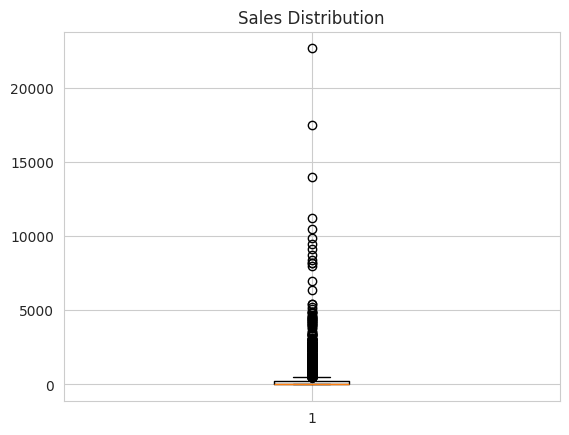

In [14]:
plt.boxplot(df['Sales'])
plt.title('Sales Distribution')
plt.show()

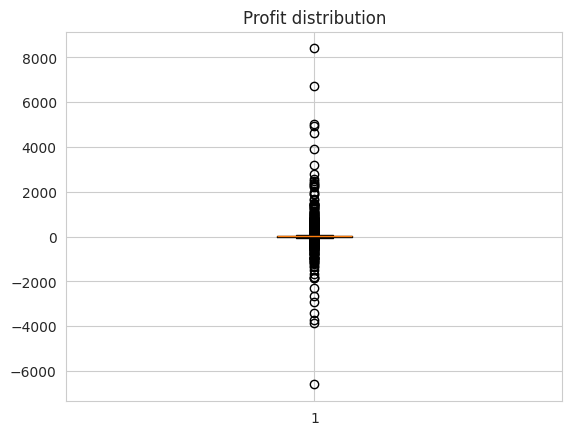

In [15]:
plt.boxplot(df['Profit'])
plt.title('Profit distribution')
plt.show()

In [16]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,7


### Observations
- No missing values
- No duplicates found or removed
- Ship Date and Order Date were object data types and converted to datatime data type
- New features such as Year, Month and Shipping days were created to support temporal and operational analysis
- Sales and Profit columns contains extreme values and outliers which is common retail transaction datasets

## 6. Exploratory Data Analysis

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Which product category generates the highest sales?

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

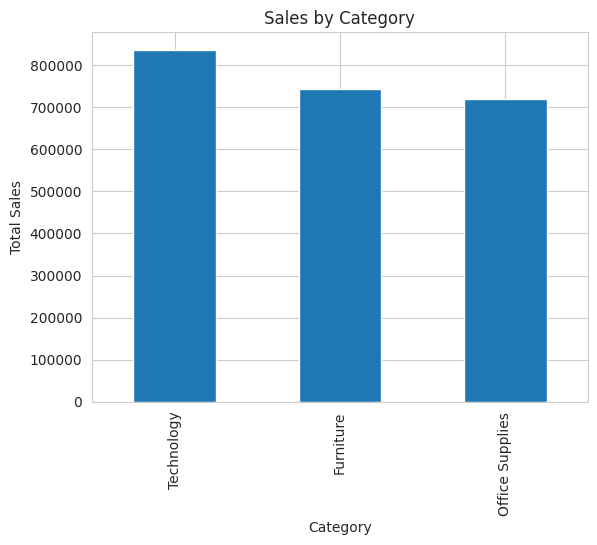

In [19]:
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

### Insights
- Technology generated the highest sales among all categories.
- Office Supplies contributed consistent sales volume.
- Furniture generated comparatively lower sales despite containing high-value products.

In [20]:
# Which Category is most profitable?

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

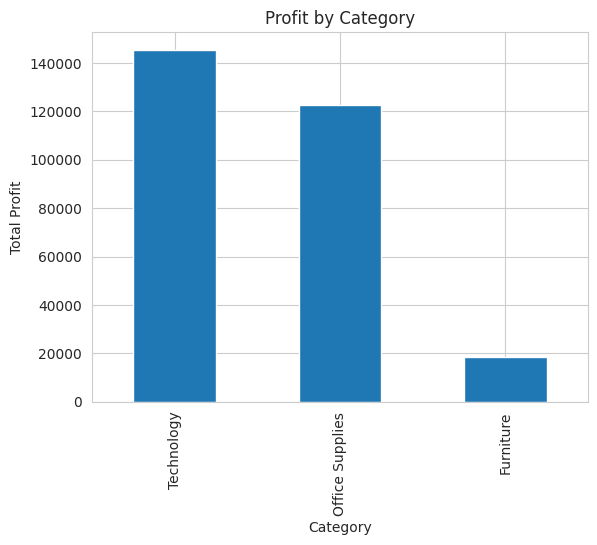

In [21]:
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.show()

### Insights
- Technology generated the highest overall profit.
- Furniture showed relatively low profitability.
- High sales do not always correspond to high profit margins.

In [22]:
# Monthly Sales Trend
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

In [23]:
month_order = ['January', 'February','March','April','May','June','July','August','September','October','November','December']
monthly_sales = df.groupby('Month')['Sales'].sum().reindex(month_order)
monthly_sales

Month
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

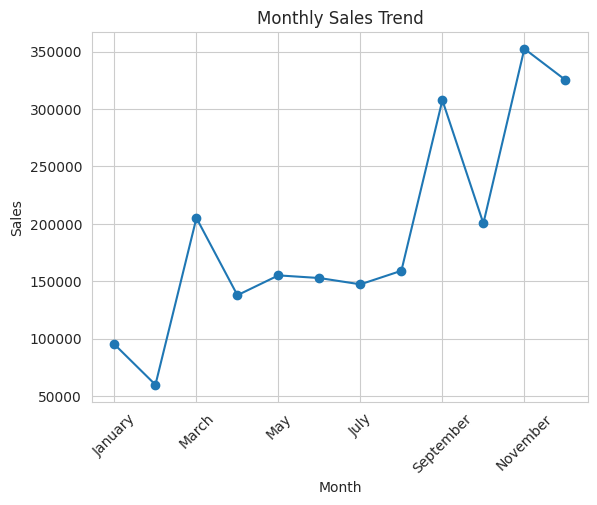

In [24]:
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation = 45)
plt.show()

### Insights
- Sales increased significantly during the later months of the year.
- Seasonal spikes suggest higher customer demand during holiday periods.
- Early months showed relatively stable sales patterns.

In [25]:
# Top states by sales

top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
top_states

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

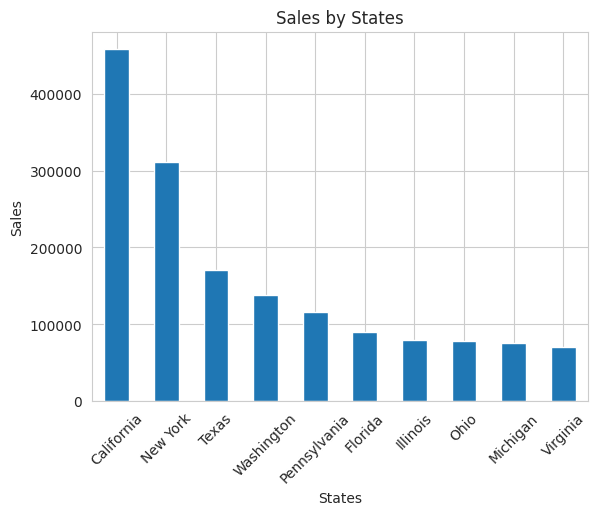

In [26]:
top_states.plot(kind='bar')
plt.title('Sales by States')
plt.xlabel('States')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

### Insights
- California generated the highest sales among all states.
- Large population and business activity may contribute to higher sales volumes.
- Sales distribution is concentrated among a few major states.

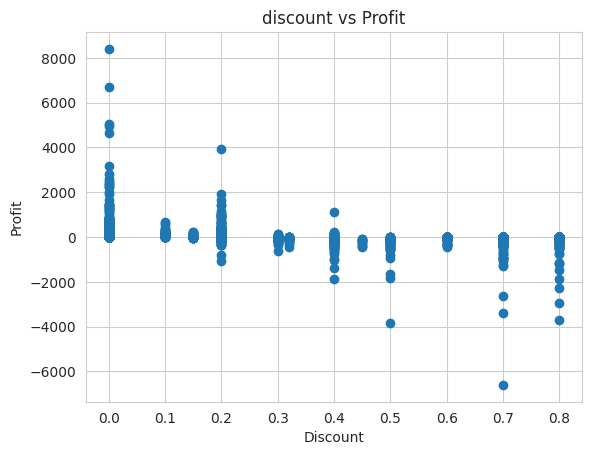

In [27]:
# Discount vs Profit Analysis
plt.scatter(df['Discount'], df['Profit'])
plt.title('discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

### Insights
- Higher discounts are often associated with lower profits.
- Several heavily discounted transactions resulted in financial losses.
- Excessive discounting negatively impacts profitability.

In [28]:
# Loss Making Products

loss_products = df[df['Profit'] < 0]
loss_products[['Product Name', 'Category','Profit']].head(10)

,Product Name,Category,Profit
3,Bretford CR4500 Series Slim Rectangular Table,Furniture,-383.0310
14,Holmes Replacement Filter for HEPA Air Cleaner...,Office Supplies,-123.8580
15,Storex DuraTech Recycled Plastic Frosted Binders,Office Supplies,-3.8160
23,"Global Deluxe Stacking Chair, Gray",Furniture,-1.0196
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,-1665.0522
28,Avery Recycled Flexi-View Covers for Binding S...,Office Supplies,-7.0532
32,"Acco Pressboard Covers with Storage Hooks, 14 ...",Office Supplies,-5.7150
36,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",Furniture,-147.9630
38,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",Furniture,-46.9764
39,"Global Fabric Manager's Chair, Dark Gray",Furniture,-15.1470


In [29]:
top_losses = df.groupby('Product Name')['Category'].sum().sort_values().head(10)
top_losses

Product Name
Global Enterprise Series Seating Low-Back Swivel/Tilt Chairs                          Furniture
Linden 12" Wall Clock With Oak Frame                                                  Furniture
Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order             Furniture
Bush Westfield Collection Bookcases, Dark Cherry Finish, Fully Assembled              Furniture
Barricks Non-Folding Utility Table with Steel Legs, Laminate Tops                     Furniture
Bush Birmingham Collection Bookcase, Dark Cherry                                      Furniture
Ultra Commercial Grade Dual Valve Door Closer                                         Furniture
Nu-Dell EZ-Mount Plastic Wall Frames                                         FurnitureFurniture
Eldon Econocleat Chair Mats for Low Pile Carpets                             FurnitureFurniture
Hon Deluxe Fabric Upholstered Stacking Chairs, Squared Back                  FurnitureFurniture
Name: Category, dtype: obje

In [30]:
# Sales by Region

region_sales = df.groupby('Region')['Sales'].sum()
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

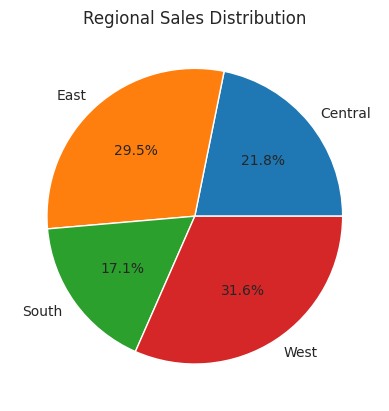

In [31]:
region_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title('Regional Sales Distribution')
plt.ylabel('')

plt.show()

## 7. Machine Learning

### Problem Definition


The objective of this project is to build a machine learning model
to predict product-level profit using retail transaction data from
the Superstore dataset.

Accurate profit prediction can help businesses understand the impact
of discounts, product categories, customer segments, and regional sales
patterns on profitability, enabling better business decisions and
resource allocation.


In [32]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Define target variable
target = 'Profit'

# Selected features
features = [
    'Sales',
    'Quantity',
    'Discount',
    'Category',
    'Sub-Category',
    'Region',
    'Segment',
    'Ship Mode'
]

# Create feature and target datasets
X = df[features]
y = df[target]


Feature Selection Justification:

The selected features were chosen based on business relevance and
their potential impact on retail profitability.

- Sales: Higher sales directly influence profit
- Quantity: Order volume affects revenue and operational cost
- Discount: Heavy discounts may reduce profit margins
- Category/Sub-Category: Different products have different profitability
- Region: Regional demand and operational differences impact profit
- Segment: Customer segment influences purchasing behavior
- Ship Mode: Shipping methods affect delivery cost and profit

Identifier columns such as Order ID, Customer ID, and Product ID
were excluded because they do not contribute meaningful predictive
patterns and may lead to overfitting.


In [34]:
X = pd.get_dummies(X,drop_first=True)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled,y_train)

LinearRegression()

In [38]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [39]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 67.79511261499339
RMSE: 282.4227159626424
R2 Score: -0.6450940208120892


In [40]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [41]:
y_pred_rf = rf_model.predict(X_test)

In [42]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 25.110746574391207
RMSE: 220.00895296347628
R2 Score: 0.0016744594976521032


In [43]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R2 Score': [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,67.795113,282.422716,-0.645094
1,Random Forest,25.110747,220.008953,0.001674



Model Comparison Analysis:

- Linear Regression showed poor performance, indicating that
  the relationship between features and target variable is not purely linear.

- Random Forest reduced prediction error and performed better
  due to its ability to capture nonlinear relationships.

- However, overall predictive performance remains limited because
  retail sales/profit data contains high variability and hidden business factors.


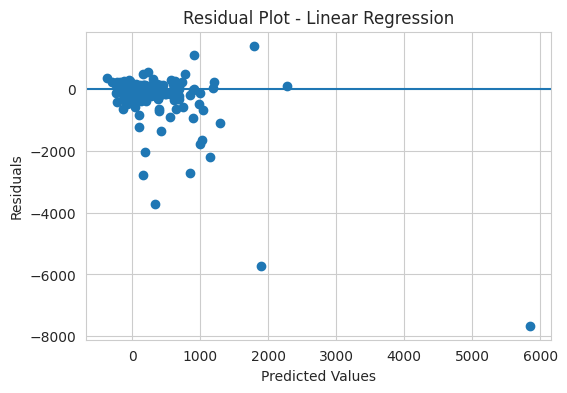

In [44]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.show()

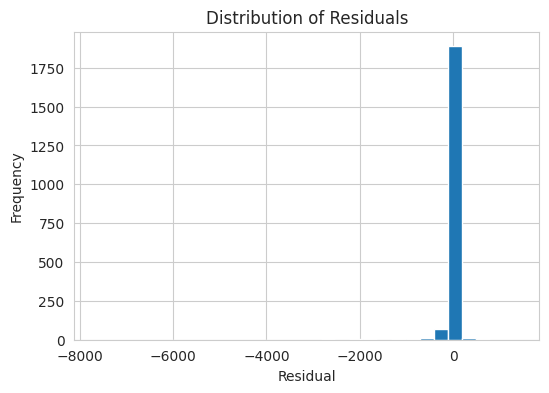

In [45]:
plt.figure(figsize=(6,4))

plt.hist(residuals, bins=30)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()


Residual Analysis Interpretation:

The residual plot does not show a completely random distribution
around zero. Residuals exhibit uneven spread and the presence of
extreme outliers, indicating that Linear Regression was unable
to fully capture the complex relationships within the retail dataset.

The increasing spread of residuals suggests heteroscedasticity,
while several extreme residual values indicate the presence of
outliers and nonlinear business patterns.

These observations justify the use of nonlinear ensemble models
such as Random Forest for improved predictive performance.


In [46]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Sales,0.744803
2,Discount,0.168370
1,Quantity,0.013230
7,Sub-Category_Binders,0.010223
24,Segment_Corporate,0.009183
10,Sub-Category_Copiers,0.008049
4,Category_Technology,0.005660
15,Sub-Category_Machines,0.004778
3,Category_Office Supplies,0.003801
21,Region_East,0.003728



Feature importance analysis revealed that Sales was the dominant
predictor influencing profit predictions, followed by Discount.

The strong contribution of Discount indicates that pricing strategies
have substantial impact on retail profitability.

Quantity and categorical business variables such as product category,
sub-category, and customer segment contributed comparatively less,
suggesting that revenue-related variables are the primary drivers
of profit variation in the dataset.


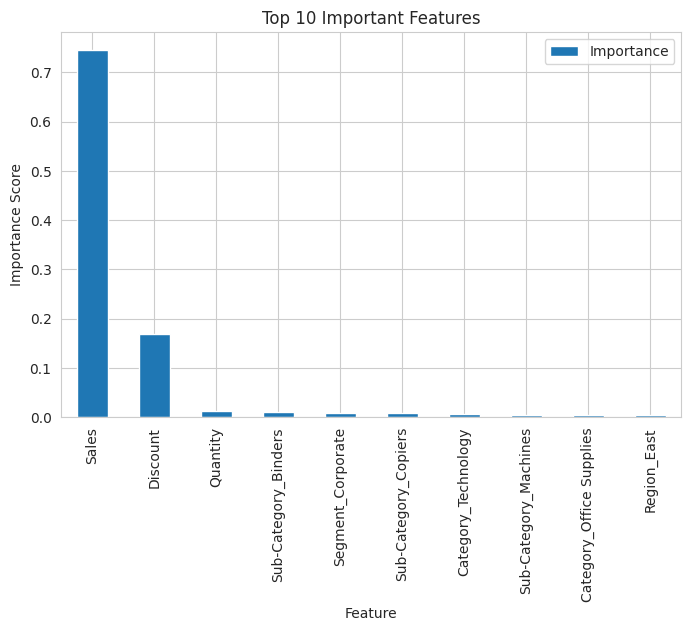

In [47]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(8,5)
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")

plt.show()

In [48]:
# =========================================================
# HYPERPARAMETER TUNING - RANDOM FOREST
# =========================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Base model
rf = RandomForestRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [49]:
# =========================================================
# PREDICTIONS
# =========================================================

y_pred_best = best_model.predict(X_test)

In [50]:
# =========================================================
# EVALUATION METRICS
# =========================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_best = mean_absolute_error(y_test, y_pred_best)

rmse_best = np.sqrt(
    mean_squared_error(y_test, y_pred_best)
)

r2_best = r2_score(y_test, y_pred_best)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("MAE :", mae_best)
print("RMSE:", rmse_best)
print("R2 Score:", r2_best)

Tuned Random Forest Performance
--------------------------------
MAE : 25.351547129992966
RMSE: 217.41737249492527
R2 Score: 0.02505535216604715


In [51]:
# =========================================================
# FINAL MODEL COMPARISON
# =========================================================

comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],

    'MAE': [
        mae,
        mae_rf,
        mae_best
    ],

    'RMSE': [
        rmse,
        rmse_rf,
        rmse_best
    ],

    'R2 Score': [
        r2,
        r2_rf,
        r2_best
    ]
})

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,67.795113,282.422716,-0.645094
1,Random Forest,25.110747,220.008953,0.001674
2,Tuned Random Forest,25.351547,217.417372,0.025055


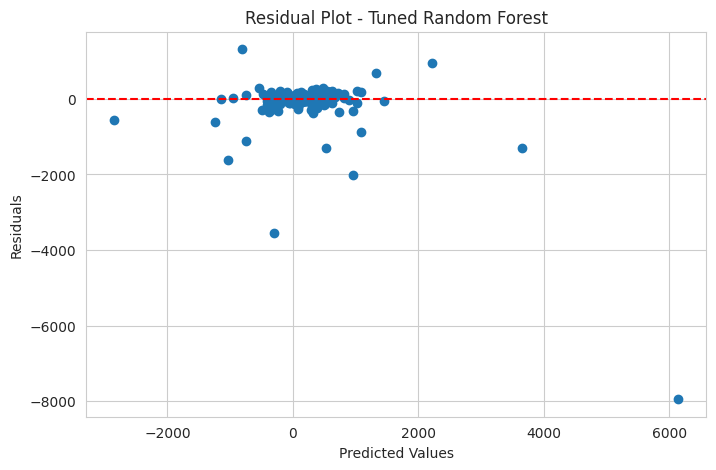

In [52]:
# =========================================================
# RESIDUAL PLOT
# =========================================================

residuals_best = y_test - y_pred_best

plt.figure(figsize=(8,5))

plt.scatter(y_pred_best, residuals_best)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Tuned Random Forest")

plt.show()


FINAL MODEL INTERPRETATION

1. Linear Regression performed poorly due to the presence of
nonlinear relationships, outliers, and high variability in the retail dataset.

2. Random Forest significantly improved prediction performance
by capturing nonlinear interactions between business variables.

3. Hyperparameter tuning further improved model stability,
resulting in lower prediction error and improved R² score.

4. Feature importance analysis revealed that Sales and Discount
were the most influential factors affecting profitability.

5. Residual analysis indicated the presence of outliers and
heteroscedasticity, highlighting the complexity of real-world
retail transaction data.

6. The project demonstrates a complete end-to-end machine learning
workflow including preprocessing, exploratory analysis, model building,
evaluation, optimization, and business interpretation.


In [53]:
df.to_csv('cleaned_superstore_data.csv', index=False)

## 8. Business Insights

## 9. Conclusion